# Data extraction: Paul Graham essays

**Step:** Load `sgoel9/paul_graham_essays` via Hugging Face → save raw snapshot (`raw_pg.csv`).

In [1]:
# Load dataset via Hugging Face
import pandas as pd

DATASET_ID = "sgoel9/paul_graham_essays"
RAW_SNAPSHOT_PATH = "raw_pg.csv"

# Option A: Hugging Face Datasets API (primary)
# from datasets import load_dataset
# ds = load_dataset(DATASET_ID, split="train")
# df = ds.to_pandas()

# Option B: Direct CSV from repo (repo hosts pual_graham_essays.csv)
import urllib.request
csv_url = "https://huggingface.co/datasets/sgoel9/paul_graham_essays/resolve/main/pual_graham_essays.csv"
urllib.request.urlretrieve(csv_url, RAW_SNAPSHOT_PATH)
df = pd.read_csv(RAW_SNAPSHOT_PATH)

# Save as our raw snapshot (canonical name)
df.to_csv(RAW_SNAPSHOT_PATH, index=False)
print(f"Saved raw snapshot to {RAW_SNAPSHOT_PATH}")

Saved raw snapshot to raw_pg.csv


In [2]:
# Show: dataset name, download method, rows, schema, license (from HF card)
from IPython.display import display

info = {
    "Dataset name": DATASET_ID,
    "Download method": "Hugging Face — direct CSV from repo (resolve/main/pual_graham_essays.csv); or load_dataset(..., split='train')",
    "Rows": len(df),
    "Schema": dict(df.dtypes),
    "License": "MIT License (attribute to Paul Graham; link: http://www.paulgraham.com/)",
}

for k, v in info.items():
    print(f"{k}: {v}")
print("\nSchema (columns + dtypes):")
display(df.dtypes)
print("\nFirst rows:")
display(df.head())

Dataset name: sgoel9/paul_graham_essays
Download method: Hugging Face — direct CSV from repo (resolve/main/pual_graham_essays.csv); or load_dataset(..., split='train')
Rows: 215
Schema: {'id': dtype('int64'), 'title': dtype('O'), 'date': dtype('O'), 'text': dtype('O')}
License: MIT License (attribute to Paul Graham; link: http://www.paulgraham.com/)

Schema (columns + dtypes):


id        int64
title    object
date     object
text     object
dtype: object


First rows:


,id,title,date,text
0,0,The Age of the Essay,September 2004,Remember the essays you had to write in high s...
1,1,A Plan for Spam,August 2002,_(This article describes the spam-filtering te...
2,2,The Trouble with the Segway,July 2009,The Segway hasn't delivered on its initial pro...
3,3,After Credentials,December 2008,A few months ago I read a _New York Times_ art...
4,4,High Resolution Fundraising,September 2010,The reason startups have been using [more conv...


---
# Data cleaning (train/val/test–ready)

Missing checks → date parsing → whitespace → markdown/footnotes → dedupe. Track rows dropped/changed per rule; show before/after snippets and summary table.

In [3]:
import re
import pandas as pd
from datetime import datetime
from hashlib import sha256

RAW_PATH = "raw_pg.csv"
CLEANED_PATH = "cleaned_pg.csv"

# --- Load raw (run extraction cells first, or load from disk) ---
df = pd.read_csv(RAW_PATH)
df = df.astype({"title": str, "date": str, "text": str})
before_text = df["text"].copy()
before_title = df["title"].copy()
before_date = df["date"].copy()
n_start = len(df)
stats = []

# --- 1. Missing: empty text, empty title, malformed date ---
empty_text = (df["text"].isna()) | (df["text"].str.strip() == "")
empty_title = (df["title"].isna()) | (df["title"].str.strip() == "")
empty_date = (df["date"].isna()) | (df["date"].str.strip() == "")
month_yyyy = re.compile(r"^(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}$", re.I)
malformed_date = ~df["date"].str.strip().str.match(month_yyyy) & ~empty_date
drop_missing = empty_text | empty_title | empty_date | malformed_date
n_drop_missing = drop_missing.sum()
df = df.loc[~drop_missing].copy()
stats.append(("Missing (empty text/title/date or malformed date)", n_drop_missing, None))

# --- 2. Parse date → date_iso (YYYY-MM-01) + year ---
MONTH = {"january": 1, "february": 2, "march": 3, "april": 4, "may": 5, "june": 6,
         "july": 7, "august": 8, "september": 9, "october": 10, "november": 11, "december": 12}

def parse_date(s):
    s = str(s).strip()
    m = re.match(r"^(January|February|March|April|May|June|July|August|September|October|November|December)\s+(\d{4})$", s, re.I)
    if not m:
        return None, None
    month_name, year = m.group(1), int(m.group(2))
    month = MONTH.get(month_name.lower())
    if month is None:
        return None, None
    date_iso = f"{year}-{month:02d}-01"
    return date_iso, year

parsed = df["date"].apply(parse_date)
df["date_iso"] = [p[0] for p in parsed]
df["year"] = [p[1] for p in parsed]
n_date = len(df)
stats.append(("Date parsed → date_iso, year", None, n_date))

# --- 3. Normalize whitespace (collapse runs, strip) ---
def norm_ws(s):
    if pd.isna(s):
        return s
    s = str(s)
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    s = re.sub(r" *\n *", "\n", s)
    return s.strip()

text_prev = df["text"].copy()
df["text"] = df["text"].apply(norm_ws)
n_ws = (text_prev != df["text"]).sum()
stats.append(("Whitespace normalized", None, n_ws))

# --- 4. Markdown links [text](url) → text only ---
def strip_links(s):
    if pd.isna(s):
        return s
    return re.sub(r"\[([^\]]*)\]\([^)]*\)", r"\1", str(s))

text_prev = df["text"].copy()
df["text"] = df["text"].apply(strip_links)
n_links = (text_prev != df["text"]).sum()
stats.append(("Markdown links → text only", None, n_links))

# --- 5. Footnote refs [1], [2] → keep as space + ref (normalized); optional: remove ---
def norm_footnotes(s):
    if pd.isna(s):
        return s
    s = str(s)
    s = re.sub(r"\[(\d+)\]", r" [\1]", s)
    return s

text_prev = df["text"].copy()
df["text"] = df["text"].apply(norm_footnotes)
n_foot = (text_prev != df["text"]).sum()
stats.append(("Footnote refs normalized", None, n_foot))

# --- 6. Boilerplate separators _ _ _ / ___ and stray formatting ---
def strip_separators(s):
    if pd.isna(s):
        return s
    s = str(s)
    s = re.sub(r"_ _ _|_  _  _|___+", "", s)
    return s

text_prev = df["text"].copy()
df["text"] = df["text"].apply(strip_separators)
n_sep = (text_prev != df["text"]).sum()
stats.append(("Separator artifacts (_ _ _, ___)", None, n_sep))

# --- 7. Strip italics _word_ and bold **word** (keep content) ---
def strip_md(s):
    if pd.isna(s):
        return s
    s = str(s)
    s = re.sub(r"\*\*([^*]+)\*\*", r"\1", s)
    s = re.sub(r"_([^_]+)_", r"\1", s)
    return s

text_prev = df["text"].copy()
df["text"] = df["text"].apply(strip_md)
n_md = (text_prev != df["text"]).sum()
stats.append(("Italics/bold stripped", None, n_md))

# --- 8. Dedupe by hash of normalized text ---
def norm_for_hash(s):
    if pd.isna(s):
        return ""
    return re.sub(r"\s+", " ", str(s).strip()).lower()

df["_text_hash"] = df["text"].apply(lambda s: sha256(norm_for_hash(s).encode()).hexdigest())
before_dedup = len(df)
df = df.drop_duplicates(subset=["_text_hash"], keep="first").drop(columns=["_text_hash"])
n_dedup = before_dedup - len(df)
stats.append(("Dedupe (hash normalized text)", n_dedup, None))

# --- Save cleaned ---
out_cols = [c for c in df.columns if not c.startswith("_")]
df_out = df[out_cols].copy()
df_out.to_csv(CLEANED_PATH, index=False)
n_final = len(df_out)

# --- Summary table ---
summary = pd.DataFrame([
    {"Rule": r[0], "Rows dropped": r[1] if r[1] is not None else 0, "Rows changed": r[2] if r[2] is not None else 0}
    for r in stats
])
summary = pd.concat([
    summary,
    pd.DataFrame([{"Rule": "Total after cleaning", "Rows dropped": n_start - n_final, "Rows changed": 0}])
], ignore_index=True)
cleaning_stats = summary
cleaned_df = df_out
# Before/after for first remaining row (by original index)
first_ix = cleaned_df.index[0] if len(cleaned_df) else 0
snippet_before_raw = (before_text.loc[first_ix][:600] if first_ix in before_text.index else "") or ""
snippet_after_raw = (cleaned_df["text"].iloc[0][:600] if len(cleaned_df) else "") or ""
print(f"Cleaned data saved to {CLEANED_PATH} ({n_final} rows, started with {n_start})")

Cleaned data saved to cleaned_pg.csv (212 rows, started with 215)


In [4]:
# --- Before/after snippets (1–2) + table of rows dropped/changed ---
import re
from IPython.display import display

print("--- Snippet 1: first essay (start of text) ---")
print("BEFORE:")
print(snippet_before_raw)
print("\nAFTER:")
print(snippet_after_raw)

# Snippet 2: a row still in cleaned set that had markdown links
link_ix = next(
    (i for i in cleaned_df.index if re.search(r"\[[^\]]+\]\([^)]+\)", str(before_text.loc[i]))),
    None,
)
if link_ix is not None:
    b = str(before_text.loc[link_ix])
    a = str(cleaned_df.loc[link_ix, "text"])
    # show a short window that contains a link
    pos = b.find("](")
    if pos >= 0:
        start = max(0, pos - 120)
        window = 380
        print("\n--- Snippet 2: paragraph with link/footnote ---")
        print("BEFORE:")
        print(b[start : start + window])
        print("\nAFTER:")
        print(a[start : start + window])

print("\n--- Rows dropped / changed per rule ---")
display(cleaning_stats)

--- Snippet 1: first essay (start of text) ---
BEFORE:
Remember the essays you had to write in high school? Topic sentence, introductory paragraph, supporting paragraphs, conclusion. The conclusion being, say, that Ahab in _Moby Dick_ was a Christ-like figure.

Oy. So I'm going to try to give the other side of the story: what an essay really is, and how you write one. Or at least, how I write one.

**Mods**

The most obvious difference between real essays and the things one has to write in school is that real essays are not exclusively about English literature. Certainly schools should teach students how to write. But due to a series of historical

AFTER:
Remember the essays you had to write in high school? Topic sentence, introductory paragraph, supporting paragraphs, conclusion. The conclusion being, say, that Ahab in Moby Dick was a Christ-like figure.

Oy. So I'm going to try to give the other side of the story: what an essay really is, and how you write one. Or at least, how I wri

,Rule,Rows dropped,Rows changed
0,Missing (empty text/title/date or malformed date),3,0
1,"Date parsed → date_iso, year",0,212
2,Whitespace normalized,0,16
3,Markdown links → text only,0,198
4,Footnote refs normalized,0,0
5,"Separator artifacts (_ _ _, ___)",0,0
6,Italics/bold stripped,0,195
7,Dedupe (hash normalized text),0,0
8,Total after cleaning,3,0


---
# Step 5 — Data splits (avoid leakage)

Split at the **essay/doc level**, then inherit splits to chunks. Options: **random 80/10/10** or **time-based** (older → train, newest → test). Saves **splits.json** and doc-level CSVs; chunking step adds `split` to chunks.

In [5]:
# --- Step 5: Doc-level split → splits.json + train/val/test CSVs ---
import json
import numpy as np
import pandas as pd

CLEANED_PATH = "cleaned_pg.csv"
SPLITS_PATH = "splits.json"
# "random" (80/10/10) or "time" (older train, newest test)
SPLIT_STRATEGY = "random"
RANDOM_SEED = 42

df = pd.read_csv(CLEANED_PATH)
doc_id_col = "id" if "id" in df.columns else df.index.astype(str)
doc_ids = df[doc_id_col].astype(str).tolist()
n = len(doc_ids)

if SPLIT_STRATEGY == "time":
    # Sort by date: oldest → train, newest → test (need date_iso)
    if "date_iso" not in df.columns and "date" in df.columns:
        df = df.sort_values("date")
    else:
        df = df.sort_values("date_iso" if "date_iso" in df.columns else "date")
    doc_ids_ordered = df[doc_id_col].astype(str).tolist()
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    n_test = n - n_train - n_val
    train_ids = doc_ids_ordered[:n_train]
    val_ids = doc_ids_ordered[n_train : n_train + n_val]
    test_ids = doc_ids_ordered[n_train + n_val :]
else:
    # Random 80/10/10
    np.random.seed(RANDOM_SEED)
    perm = np.random.permutation(n)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    n_test = n - n_train - n_val
    train_ids = [doc_ids[i] for i in perm[:n_train]]
    val_ids = [doc_ids[i] for i in perm[n_train : n_train + n_val]]
    test_ids = [doc_ids[i] for i in perm[n_train + n_val :]]

splits = {
    "strategy": SPLIT_STRATEGY,
    "train": train_ids,
    "val": val_ids,
    "test": test_ids,
    "counts": {
        "train": {"docs": len(train_ids)},
        "val": {"docs": len(val_ids)},
        "test": {"docs": len(test_ids)},
    },
}
with open(SPLITS_PATH, "w") as f:
    json.dump(splits, f, indent=2)

# Doc-level CSVs
df["_doc_id_str"] = df[doc_id_col].astype(str)
train_df = df[df["_doc_id_str"].isin(train_ids)].drop(columns=["_doc_id_str"])
val_df = df[df["_doc_id_str"].isin(val_ids)].drop(columns=["_doc_id_str"])
test_df = df[df["_doc_id_str"].isin(test_ids)].drop(columns=["_doc_id_str"])
train_df.to_csv("train_pg.csv", index=False)
val_df.to_csv("val_pg.csv", index=False)
test_df.to_csv("test_pg.csv", index=False)

print(f"Saved {SPLITS_PATH} (strategy={SPLIT_STRATEGY})")
print("Counts per split (docs):", splits["counts"])
print("Saved train_pg.csv, val_pg.csv, test_pg.csv")

Saved splits.json (strategy=random)
Counts per split (docs): {'train': {'docs': 169}, 'val': {'docs': 21}, 'test': {'docs': 22}}
Saved train_pg.csv, val_pg.csv, test_pg.csv


---
# Augmentation (RAG + more training samples)

Chunk essays into retrieval units → **pg_chunks.parquet** (doc_id, chunk_id, chunk_text, chunk_word_count, chunk_index, overlap, source, format). Turns ~215 docs into 1000–2000+ chunks for embedding + retrieval.

In [6]:
import pandas as pd
from IPython.display import display

CLEANED_PATH = "cleaned_pg.csv"
CHUNKS_PATH = "pg_chunks.parquet"

# Chunking config: ~256 words per chunk, 50-word overlap → ~1000–2000+ chunks from 215 essays
CHUNK_SIZE = 256
OVERLAP = 50
SOURCE = "paul_graham_essays"
FORMAT = "essay"

df = pd.read_csv(CLEANED_PATH)
# use id as doc_id; if id missing use index
df["doc_id"] = df["id"].astype(str) if "id" in df.columns else df.index.astype(str)

def chunk_text(text, size, overlap):
    if pd.isna(text) or not str(text).strip():
        return []
    words = str(text).split()
    step = max(1, size - overlap)
    chunks = []
    for start in range(0, len(words), step):
        window = words[start : start + size]
        if not window:
            break
        chunks.append(" ".join(window))
        if start + size >= len(words):
            break
    return chunks

rows = []
global_chunk_id = 0
for _, row in df.iterrows():
    doc_id = row["doc_id"]
    text = row["text"]
    chunks = chunk_text(text, CHUNK_SIZE, OVERLAP)
    for chunk_index, ct in enumerate(chunks):
        word_count = len(ct.split())
        rows.append({
            "doc_id": doc_id,
            "chunk_id": str(global_chunk_id),
            "chunk_text": ct,
            "chunk_word_count": word_count,
            "chunk_index": chunk_index,
            "overlap": OVERLAP,
            "source": SOURCE,
            "format": FORMAT,
        })
        global_chunk_id += 1

chunks_df = pd.DataFrame(rows)

# Inherit splits from splits.json (run Step 5 first)
import json
SPLITS_PATH = "splits.json"
try:
    with open(SPLITS_PATH) as f:
        splits = json.load(f)
    doc_to_split = {}
    for s in ("train", "val", "test"):
        for doc_id in splits.get(s, []):
            doc_to_split[str(doc_id)] = s
    chunks_df["split"] = chunks_df["doc_id"].astype(str).map(doc_to_split).fillna("unknown")
    # Update splits.json with chunk counts
    for s in ("train", "val", "test"):
        splits["counts"][s]["chunks"] = int((chunks_df["split"] == s).sum())
    with open(SPLITS_PATH, "w") as f:
        json.dump(splits, f, indent=2)
    print("Inherited splits to chunks; updated", SPLITS_PATH, "with chunk counts")
    print("Counts per split:", splits["counts"])
except FileNotFoundError:
    chunks_df["split"] = "train"  # default if Step 5 not run
    print("splits.json not found; chunks have no split (run Step 5 first).")

chunks_df.to_parquet(CHUNKS_PATH, index=False)
print(f"\nSaved {CHUNKS_PATH}: {len(chunks_df)} chunks from {len(df)} docs")
print("Schema:", list(chunks_df.columns))
print("\nFirst rows:")
display(chunks_df.head())
print("\nChunks per doc (min/median/max):", chunks_df.groupby("doc_id").size().agg(["min", "median", "max"]).to_dict())

Inherited splits to chunks; updated splits.json with chunk counts
Counts per split: {'train': {'docs': 169, 'chunks': 2098}, 'val': {'docs': 21, 'chunks': 228}, 'test': {'docs': 22, 'chunks': 208}}

Saved pg_chunks.parquet: 2534 chunks from 212 docs
Schema: ['doc_id', 'chunk_id', 'chunk_text', 'chunk_word_count', 'chunk_index', 'overlap', 'source', 'format', 'split']

First rows:


,doc_id,chunk_id,chunk_text,chunk_word_count,chunk_index,overlap,source,format,split
0,0,0,Remember the essays you had to write in high s...,256,0,50,paul_graham_essays,essay,train
1,0,1,"thousand years. Around 1100, Europe at last be...",256,1,50,paul_graham_essays,essay,train
2,0,2,obvious reasons no one wanted to give that ans...,256,2,50,paul_graham_essays,essay,train
3,0,3,"do original math, the professors who taught hi...",256,3,50,paul_graham_essays,essay,train
4,0,4,real work: the students are imitating English ...,256,4,50,paul_graham_essays,essay,train



Chunks per doc (min/median/max): {'min': 1.0, 'median': 8.0, 'max': 67.0}


---
# EDA (statistics + visuals + insights)

Supports **“analyze writing samples / style”**: word-count distribution, essays per year, top terms/bigrams, optional readability. Uses cleaned doc-level data.

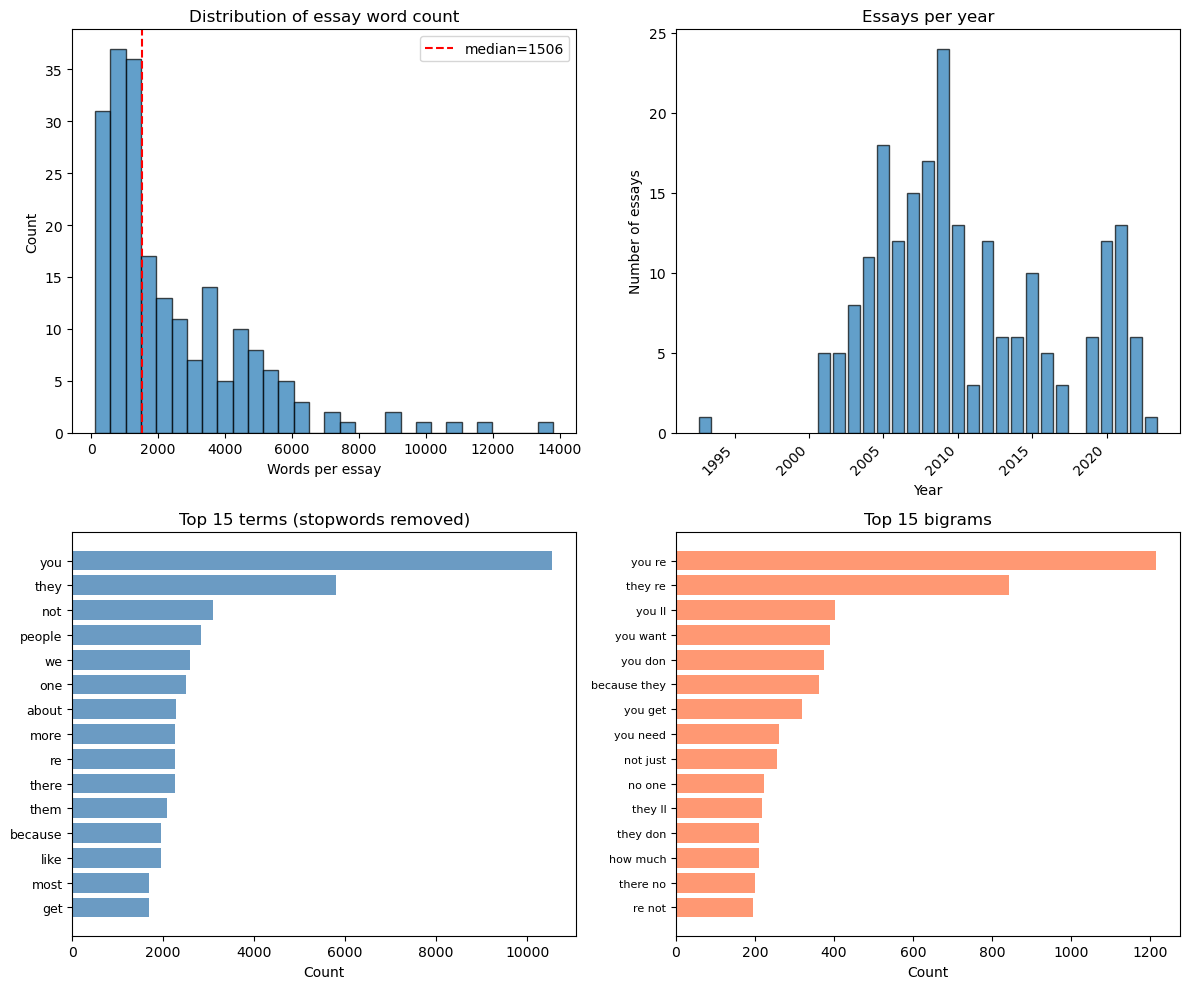

Top 10 terms: [('you', 10551), ('they', 5788), ('not', 3100), ('people', 2828), ('we', 2599), ('one', 2492), ('about', 2282), ('more', 2269), ('re', 2264), ('there', 2260)]
Top 10 bigrams: [('you re', 1215), ('they re', 842), ('you ll', 402), ('you want', 391), ('you don', 374), ('because they', 363), ('you get', 320), ('you need', 260), ('not just', 255), ('no one', 224)]
Readability: install 'textstat' for Flesch scores (pip install textstat).


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

CLEANED_PATH = "cleaned_pg.csv"
df = pd.read_csv(CLEANED_PATH)

# --- 1. Distribution of word count (per-essay) — histogram ---
df["word_count"] = df["text"].fillna("").apply(lambda s: len(str(s).split()))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df["word_count"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("Words per essay")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of essay word count")
axes[0, 0].axvline(df["word_count"].median(), color="red", linestyle="--", label=f"median={df['word_count'].median():.0f}")
axes[0, 0].legend()

# --- 2. Essays per year (bar chart) — after date parsing ---
year_col = "year" if "year" in df.columns else "date_iso"
if year_col == "date_iso" and year_col in df.columns:
    df["_year"] = pd.to_datetime(df["date_iso"], errors="coerce").dt.year
else:
    df["_year"] = df[year_col]
counts_by_year = df["_year"].dropna().astype(int).value_counts().sort_index()
axes[0, 1].bar(counts_by_year.index, counts_by_year.values, edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of essays")
axes[0, 1].set_title("Essays per year")
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha="right")

# --- 3. Top terms and bigrams (after cleaning) ---
def tokenize(s):
    if pd.isna(s):
        return []
    return re.findall(r"[a-z]+", str(s).lower())

all_tokens = []
for t in df["text"].fillna(""):
    all_tokens.extend(tokenize(t))
stop = {"the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with", "by", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "do", "does", "did", "will", "would", "could", "should", "may", "might", "must", "can", "this", "that", "these", "those", "it", "its", "as", "so", "if", "then", "than", "when", "what", "which", "who", "from"}
terms = [w for w in all_tokens if w not in stop and len(w) > 1]
bigrams = [tuple(terms[i : i + 2]) for i in range(len(terms) - 1)]
top_n = 15
top_terms = Counter(terms).most_common(top_n)
top_bigrams = Counter(bigrams).most_common(top_n)

words, cnt = zip(*top_terms)
axes[1, 0].barh(range(len(words)), cnt, color="steelblue", alpha=0.8)
axes[1, 0].set_yticks(range(len(words)))
axes[1, 0].set_yticklabels(words, fontsize=9)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_title("Top 15 terms (stopwords removed)")
bg_labels = [" ".join(b) for b, _ in top_bigrams]
axes[1, 1].barh(range(len(bg_labels)), [c for _, c in top_bigrams], color="coral", alpha=0.8)
axes[1, 1].set_yticks(range(len(bg_labels)))
axes[1, 1].set_yticklabels(bg_labels, fontsize=8)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_title("Top 15 bigrams")

plt.tight_layout()
plt.show()

print("Top 10 terms:", top_terms[:10])
print("Top 10 bigrams:", [( " ".join(b), c) for b, c in top_bigrams[:10]])

# --- 4. Readability stats (optional) ---
try:
    import textstat
    def readability(s):
        if pd.isna(s) or not str(s).strip():
            return None
        return textstat.flesch_reading_ease(str(s))
    df["flesch"] = df["text"].apply(readability)
    df_read = df["flesch"].dropna()
    if len(df_read):
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(df_read, bins=25, edgecolor="black", alpha=0.7)
        ax.set_xlabel("Flesch reading ease (higher = easier)")
        ax.set_ylabel("Essays")
        ax.set_title("Readability (Flesch) distribution")
        plt.tight_layout()
        plt.show()
        print("Readability (Flesch): mean = {:.1f}, median = {:.1f}".format(df_read.mean(), df_read.median()))
    else:
        print("Readability: no valid scores (install textstat if needed).")
except ImportError:
    print("Readability: install 'textstat' for Flesch scores (pip install textstat).")

---
# Persona profile (structured “voice spec”)

From the cleaned PG corpus: **vocabulary tendencies**, **structure patterns**, **favorite framing**, **favorite themes**. Output: **persona_profile_pg.json** (human-readable, usable by prompt constructor).

In [8]:
import json
import re
import pandas as pd
from collections import Counter

CLEANED_PATH = "cleaned_pg.csv"
PROFILE_PATH = "persona_profile_pg.json"

df = pd.read_csv(CLEANED_PATH)
texts = df["text"].fillna("").astype(str).tolist()
corpus = " ".join(texts).lower()

# --- Tokenize helpers ---
def tokenize(s):
    return re.findall(r"[a-z]+", s.lower()) if s else []

def sentences(s):
    return [t.strip() for t in re.split(r"[.!?]+", s) if t.strip()]

def paragraphs(s):
    return [p.strip() for p in re.split(r"\n\s*\n", s) if p.strip()]

# --- 1. Vocabulary tendencies ---
all_tokens = tokenize(corpus)
stop = {"the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with", "by", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "do", "does", "did", "will", "would", "could", "should", "may", "might", "must", "can", "this", "that", "these", "those", "it", "its", "as", "so", "if", "then", "than", "when", "what", "which", "who", "from"}
content_words = [w for w in all_tokens if w not in stop and len(w) > 1]
word_freq = Counter(content_words)
vocab_tendencies = {
    "top_50_content_words": [w for w, _ in word_freq.most_common(50)],
    "avg_word_length": round(sum(len(w) for w in all_tokens) / max(1, len(all_tokens)), 2),
    "lexical_diversity": round(len(set(all_tokens)) / max(1, len(all_tokens)), 3),
    "total_tokens": len(all_tokens),
    "unique_tokens": len(set(all_tokens)),
}

# --- 2. Structure patterns ---
all_sents = []
all_paras = []
for t in texts:
    all_sents.extend(sentences(t))
    all_paras.extend(paragraphs(t))
sent_lens = [len(tokenize(s)) for s in all_sents if s]
para_lens = [len(sentences(p)) for p in all_paras if p]
starters = []
for s in all_sents:
    words = tokenize(s)
    if len(words) >= 2:
        starters.append(" ".join(words[:2]))
    elif len(words) == 1:
        starters.append(words[0])
starter_freq = Counter(starters)
structure_patterns = {
    "avg_sentence_length_words": round(sum(sent_lens) / max(1, len(sent_lens)), 1) if sent_lens else 0,
    "avg_paragraph_length_sentences": round(sum(para_lens) / max(1, len(para_lens)), 1) if para_lens else 0,
    "common_sentence_starters_bigrams": [s for s, _ in starter_freq.most_common(25)],
}

# --- 3. Favorite framing ---
framing_phrases = [
    "i think", "the thing", "what matters", "one thing", "the key", "the reason", "the problem",
    "the best", "the most", "the way", "it seems", "it turns", "in fact", "of course",
    "for example", "the answer", "the question", "the difference", "the point", "the real",
]
phrase_counts = {}
for p in framing_phrases:
    phrase_counts[p] = len(re.findall(r"\b" + re.escape(p) + r"\b", corpus))
first_person = len(re.findall(r"\b(i|me|my|we|us|our)\b", corpus))
second_person = len(re.findall(r"\b(you|your)\b", corpus))
questions = sum(1 for s in all_sents if s.strip().endswith("?"))
favorite_framing = {
    "favorite_framing_phrases": [p for p in framing_phrases if phrase_counts[p] > 0],
    "framing_phrase_counts": {p: c for p, c in phrase_counts.items() if c > 0},
    "first_person_mentions": first_person,
    "second_person_mentions": second_person,
    "question_sentences_count": questions,
    "rhetorical_style_note": "Uses questions and direct address (you) frequently; first-person reflection common.",
}

# --- 4. Favorite themes ---
bigrams = [tuple(content_words[i : i + 2]) for i in range(len(content_words) - 1)]
bigram_freq = Counter(bigrams)
theme_candidates = (
    [w for w, _ in word_freq.most_common(80)]
    + [" ".join(b) for b, _ in bigram_freq.most_common(40)]
)
# Dedupe and take top theme-like items (words + meaningful bigrams)
seen = set()
favorite_themes = []
for x in theme_candidates:
    if x in seen or len(x) < 3:
        continue
    seen.add(x)
    favorite_themes.append(x)
    if len(favorite_themes) >= 40:
        break

# --- Section headers as themes (e.g. **Mods** in PG essays) ---
section_headers = []
for t in texts:
    section_headers.extend(re.findall(r"(?<=\n)\s*([A-Za-z][A-Za-z0-9\s]{2,40})\s*(?=\n)", t))
section_freq = Counter(s.strip() for s in section_headers if 3 <= len(s.strip()) <= 40)
top_section_themes = [s for s, _ in section_freq.most_common(15)]

profile = {
    "name": "Paul Graham (essays)",
    "source": "paul_graham_essays",
    "description": "Structured voice spec derived from cleaned PG essay corpus for prompt construction and style alignment.",
    "vocabulary_tendencies": vocab_tendencies,
    "structure_patterns": structure_patterns,
    "favorite_framing": favorite_framing,
    "favorite_themes": {
        "top_content_words_and_bigrams": favorite_themes[:40],
        "section_style_headers_sample": top_section_themes,
    },
}

with open(PROFILE_PATH, "w") as f:
    json.dump(profile, f, indent=2)

print(f"Saved {PROFILE_PATH}")
print("Sample (vocabulary_tendencies.top_50_content_words):", profile["vocabulary_tendencies"]["top_50_content_words"][:15])
print("Sample (structure_patterns.common_sentence_starters_bigrams):", profile["structure_patterns"]["common_sentence_starters_bigrams"][:10])
print("Sample (favorite_framing.favorite_framing_phrases):", profile["favorite_framing"]["favorite_framing_phrases"])

Saved persona_profile_pg.json
Sample (vocabulary_tendencies.top_50_content_words): ['you', 'they', 'not', 'people', 'we', 'one', 'about', 'more', 're', 'there', 'them', 'because', 'like', 'most', 'get']
Sample (structure_patterns.common_sentence_starters_bigrams): ['it s', 'if you', 'that s', 'you can', 'there are', 'this is', 'i m', 'i think', 'for example', 'when you']
Sample (favorite_framing.favorite_framing_phrases): ['i think', 'the thing', 'what matters', 'one thing', 'the key', 'the reason', 'the problem', 'the best', 'the most', 'the way', 'it seems', 'it turns', 'in fact', 'of course', 'for example', 'the answer', 'the question', 'the difference', 'the point', 'the real']


---
# Step 8 — Embed + index (RAG prototype)

Embed **pg_chunks** (+ optional approved reference chunks) and store in a **vector DB (Chroma)**. Enables retrieval of relevant past writing + references for RAG.

In [10]:
pip install chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.4 MB/s eta 0:00:00
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached oauthlib-3.3.1-py3-none-any.whl.metadata (7.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 118.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 106.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 123.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
# Step 9 — Prompt constructor (format-aware)

Define a **content brief** schema (`topic`, `audience`, `goal`, `draft`, `length`, `call_to_action`) and build prompts as:

> **Prompt = persona_profile + retrieved chunks + brief → LLM draft**

In [ ]:
import json
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

PERSONA_PROFILE_PATH = "persona_profile_pg.json"

@dataclass
class ContentBrief:
    """Schema for PG-style content generation.

    - topic: subject or working title
    - audience: who the piece is for
    - goal: what the piece should achieve
    - draft: optional rough draft or notes (can be empty)
    - length: expected length / format hint (e.g. "tweet", "short", "medium blog", "long essay")
    - call_to_action: desired reader action at the end (or "none")
    """

    topic: str
    audience: str
    goal: str
    draft: str = ""
    length: str = "medium blog"
    call_to_action: str = "none"

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


def load_persona_profile(path: str = PERSONA_PROFILE_PATH) -> Dict[str, Any]:
    with open(path) as f:
        return json.load(f)


def summarize_persona(profile: Dict[str, Any]) -> str:
    """Turn persona_profile_pg.json into a compact, LLM-friendly instructions block."""
    vocab = profile.get("vocabulary_tendencies", {})
    structure = profile.get("structure_patterns", {})
    framing = profile.get("favorite_framing", {})
    themes = profile.get("favorite_themes", {})

    top_words = ", ".join(vocab.get("top_50_content_words", [])[:15])
    starters = ", ".join(structure.get("common_sentence_starters_bigrams", [])[:8])
    framing_phrases = ", ".join(framing.get("favorite_framing_phrases", [])[:10])
    theme_examples = ", ".join(themes.get("top_content_words_and_bigrams", [])[:10])

    lines = [
        "You are writing in the persona of Paul Graham's essays.",
        "Emulate the following tendencies:",
        f"- Vocabulary: prefer concrete, plain language with frequent use of: {top_words}.",
        f"- Structure: conversational essay style, with medium-length sentences (avg ~{structure.get('avg_sentence_length_words', 'N/A')} words) and sections that build an argument.",
        f"  Common sentence openers to echo (sparingly): {starters}.",
        f"- Framing: often uses reflective phrases like: {framing_phrases}.",
        f"- Themes to lean on: {theme_examples}.",
        "Avoid corporate/marketing buzzwords. Prefer clear, direct reasoning and concrete examples.",
    ]
    return "\n".join(lines)


def format_brief_section(brief: ContentBrief) -> str:
    b = brief.to_dict()
    return "\n".join([
        "[CONTENT BRIEF]",
        f"Topic: {b['topic']}",
        f"Audience: {b['audience']}",
        f"Goal: {b['goal']}",
        f"Desired length / format: {b['length']}",
        f"Call to action: {b['call_to_action']}",
        f"Existing draft or notes: {b['draft'] or 'N/A'}",
    ])


def format_context_section(retrieved_chunks: List[Dict[str, Any]], max_chars: int = 4000) -> str:
    """Format retrieved chunks into a context block, truncated to max_chars.

    Each chunk is expected to be a dict with at least `chunk_text` and optionally metadata
    like `doc_id`, `chunk_index`, `source`, `format`, `split`.
    """
    lines = ["[CONTEXT — EXCERPTS FROM PG ESSAYS]"]
    total = 0
    for i, ch in enumerate(retrieved_chunks):
        text = str(ch.get("chunk_text", "")).strip()
        if not text:
            continue
        header = f"[Chunk {i} — doc_id={ch.get('doc_id', '?')}, index={ch.get('chunk_index', '?')}]"
        snippet = text
        if total + len(header) + len(snippet) + 2 > max_chars:
            # Truncate last snippet if needed
            remaining = max_chars - total - len(header) - 5
            if remaining <= 0:
                break
            snippet = snippet[:remaining] + "..."
        lines.append(header)
        lines.append(snippet)
        total += len(header) + len(snippet) + 2
        if total >= max_chars:
            break
    return "\n".join(lines)


def build_pg_prompt(brief: ContentBrief, retrieved_chunks: List[Dict[str, Any]], persona_profile: Dict[str, Any] | None = None) -> str:
    """Construct a single prompt string for an LLM.

    Usage:
        profile = load_persona_profile()
        brief = ContentBrief(...)
        prompt = build_pg_prompt(brief, retrieved_chunks, profile)
    """
    if persona_profile is None:
        persona_profile = load_persona_profile()

    persona_block = summarize_persona(persona_profile)
    brief_block = format_brief_section(brief)
    context_block = format_context_section(retrieved_chunks)

    instructions = (
        "You are an assistant writing in the style of Paul Graham's essays. "
        "Use the persona guidance, context excerpts, and content brief below to draft a single coherent piece. "
        "Cite or echo the context conceptually, but do not copy long spans verbatim. "
        "Write directly to the specified audience, keeping the stated goal and call-to-action in mind."
    )

    prompt = "\n\n".join([
        "[PERSONA]",
        persona_block,
        brief_block,
        context_block,
        "[INSTRUCTIONS]",
        instructions,
        "[OUTPUT]\nWrite the requested draft in one continuous piece, with clear paragraphs and no surrounding commentary.",
    ])
    return prompt


# Example (for testing in the notebook, not used by pipeline directly):
if __name__ == "__main__":
    example_brief = ContentBrief(
        topic="Why founders should write more essays",
        audience="early-stage B2B SaaS founders",
        goal="explain why writing long-form essays clarifies thinking and attracts the right investors",
        length="short essay (800–1200 words)",
        call_to_action="encourage founders to publish one substantive essay this month",
    )
    # Minimal fake retrieved chunk; in practice use top-k from Chroma
    fake_chunks = [{"chunk_text": "Writing is a way to think out loud. Most of what ends up in my essays I only thought of when I sat down to write them.", "doc_id": "0", "chunk_index": 0}]
    profile = load_persona_profile()
    demo_prompt = build_pg_prompt(example_brief, fake_chunks, profile)
    print("\n--- Demo prompt (truncated) ---\n")
    print(demo_prompt[:1000] + "...\n[truncated]")

In [11]:
# pip install chromadb sentence-transformers
import pandas as pd
import chromadb
from chromadb.config import Settings

CHUNKS_PATH = "pg_chunks.parquet"
REFERENCE_CHUNKS_PATH = "reference_chunks.parquet"  # optional: approved reference chunks (same schema)
CHROMA_PERSIST_DIR = "chroma_pg"
COLLECTION_NAME = "pg_essays"

# Load main chunks
chunks_df = pd.read_parquet(CHUNKS_PATH)
chunks_df = chunks_df.astype(str, errors="ignore")
texts = chunks_df["chunk_text"].tolist()
ids = chunks_df["chunk_id"].tolist()
metadatas = chunks_df[["doc_id", "chunk_index", "split", "source", "format"]].to_dict("records")
for m in metadatas:
    for k, v in m.items():
        m[k] = str(v)[:100]  # Chroma metadata length limit

# Optional: append approved reference chunks (e.g. style guide, approved quotes)
try:
    ref_df = pd.read_parquet(REFERENCE_CHUNKS_PATH)
    ref_df = ref_df.astype(str, errors="ignore")
    ref_texts = ref_df["chunk_text"].tolist()
    ref_ids = ["ref_" + str(i) for i in range(len(ref_texts))]
    ref_metadatas = [{"doc_id": "reference", "split": "reference", "source": "reference", "format": "reference"} for _ in ref_texts]
    texts = texts + ref_texts
    ids = ids + ref_ids
    metadatas = metadatas + ref_metadatas
    print(f"Added {len(ref_texts)} reference chunks")
except FileNotFoundError:
    print("No reference_chunks.parquet found; indexing pg_chunks only.")

# Embed with sentence-transformers (no API key; runs locally)
print("Loading embedding model...")
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts, show_progress_bar=True)

# Persist Chroma to disk
client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR, settings=Settings(anonymized_telemetry=False))
collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    metadata={"description": "PG essay chunks + references for RAG"},
)
# Upsert in batches (Chroma accepts list of ids, documents, metadatas, embeddings)
batch_size = 256
for i in range(0, len(ids), batch_size):
    end = min(i + batch_size, len(ids))
    collection.upsert(
        ids=ids[i:end],
        documents=texts[i:end],
        metadatas=metadatas[i:end],
        embeddings=embeddings[i:end].tolist(),
    )
print(f"Indexed {len(ids)} chunks in Chroma at '{CHROMA_PERSIST_DIR}' (collection: {COLLECTION_NAME})")

# Quick sanity query
results = collection.query(query_embeddings=model.encode(["What makes a good essay?"]).tolist(), n_results=3)
print("Sample query 'What makes a good essay?' — top 3 ids:", results["ids"][0])

No reference_chunks.parquet found; indexing pg_chunks only.
Loading embedding model...


Batches:   0%|          | 0/80 [00:00<?, ?it/s]

Indexed 2534 chunks in Chroma at 'chroma_pg' (collection: pg_essays)
Sample query 'What makes a good essay?' — top 3 ids: ['12', '2352', '9']
